<a href="https://colab.research.google.com/github/SaymaSJ/Machine-learning-project-practice/blob/main/USed_car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Import all the libraries***

In [ ]:
import numpy as np

In [ ]:
import pandas as pd
from sklearn import linear_model
import warnings
warnings.filterwarnings('ignore')


import matplotlib.pyplot as plt
import seaborn as sns
reg=linear_model.LinearRegression()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score , mean_absolute_error
from sklearn.preprocessing import OneHotEncoder , StandardScaler , LabelEncoder


**load the data**

In [ ]:
df=pd.read_csv("/content/used_cars.csv")
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


**Clean the data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [ ]:
df.isna().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

print("\nDescriptive statistics for categorical columns:")
display(df.describe(include='object'))

Descriptive statistics for numerical columns:


,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000



Descriptive statistics for categorical columns:


,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


In [ ]:
df_cleaned=df.dropna()

In [ ]:
print("\ndescriptive statistics after cleaning:")
print(df_cleaned.describe())


descriptive statistics after cleaning:
        model_year
count  3269.000000
mean   2014.601407
std       6.152181
min    1974.000000
25%    2011.000000
50%    2016.000000
75%    2019.000000
max    2024.000000


**Train and Test the data**

### Data Preprocessing: Clean and Convert to Numerical

In [ ]:
# Ensure X and Y are defined before preprocessing
X = df_cleaned.drop("price", axis=1)
Y = df_cleaned["price"]

# Clean and convert 'milage' to numeric (float)
X['milage'] = X['milage'].str.replace(' mi.', '').str.replace(',', '').astype(float)

# Clean and convert 'price' (Y) to numeric (float)
Y = Y.str.replace('$', '').str.replace(',', '').astype(float)

# Display the updated types and first few rows to verify
print("X 'milage' dtype:", X['milage'].dtype)
print("Y dtype:", Y.dtype)
display(X.head())
display(Y.head())

X 'milage' dtype: float64
Y dtype: float64


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes
6,Audi,S3 2.0T Premium Plus,2017,84000.0,Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes
7,BMW,740 iL,2001,242000.0,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes


,price
0,10300.0
1,38005.0
3,15500.0
6,31000.0
7,7300.0


### One-Hot Encode Categorical Features

In [ ]:
# Identify categorical columns for one-hot encoding
categorical_cols = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply one-hot encoding to the selected columns
encoded_features = ohe.fit_transform(X[categorical_cols])

# Create a DataFrame from the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=ohe.get_feature_names_out(categorical_cols), index=X.index)

# Drop the original categorical columns from X and concatenate the encoded features
X = X.drop(columns=categorical_cols)
X = pd.concat([X, encoded_df], axis=1)

# Display the first few rows of the updated X to verify
print("Shape of X after one-hot encoding:", X.shape)
display(X.head())

Shape of X after one-hot encoding: (3269, 2867)


,model_year,milage,brand_Acura,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Bugatti,brand_Buick,...,int_col_Sport,int_col_Tan,int_col_Titan Black / Quarzit,int_col_White,int_col_White / Brown,int_col_Yellow,int_col_–,accident_At least 1 accident or damage reported,accident_None reported,clean_title_Yes
0,2013,51000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,2021,34742.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,2015,88900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
6,2017,84000.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
7,2001,242000.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


### Split Data into Training and Testing Sets

In [ ]:
# Split the data into training and testing sets
# Using a 80/20 split, with a random state for reproducibility
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of Y_train: {Y_train.shape}")
print(f"Shape of Y_test: {Y_test.shape}")

Shape of X_train: (2615, 2867)
Shape of X_test: (654, 2867)
Shape of Y_train: (2615,)
Shape of Y_test: (654,)


### Train Model on Training Data

In [ ]:
# Initialize and train the Linear Regression model on the training data
model_split = LinearRegression()
model_split.fit(X_train, Y_train)

print("Model training complete on training data.")

Model training complete on training data.


### Make Predictions on Test Data

In [ ]:
# Make predictions on the test set
Y_pred_split = model_split.predict(X_test)

print("Predictions on test data complete.")

Predictions on test data complete.


### Evaluate Model Performance on Test Data

In [ ]:
# Ensure the functions are used, not shadowed variables
# This addresses a persistent TypeError if global variables with the same names were previously defined
if 'mean_squared_error' in globals() and isinstance(globals()['mean_squared_error'], float):
    del mean_squared_error
if 'mean_absolute_error' in globals() and isinstance(globals()['mean_absolute_error'], float):
    del mean_absolute_error

# Calculate R-squared score on the test set
r2_split = r2_score(Y_test, Y_pred_split)
print(f"R-squared score on test set: {r2_split:.4f}")

# Calculate Mean Squared Error (MSE) on the test set
mse_split = mean_squared_error(Y_test, Y_pred_split)
print(f"Mean Squared Error on test set: {mse_split:.4f}")

# Calculate Mean Absolute Error (MAE) on the test set
mae_split = mean_absolute_error(Y_test, Y_pred_split)
print(f"Mean Absolute Error on test set: {mae_split:.4f}")

R-squared score on test set: 0.0644


TypeError: 'float' object is not callable

In [ ]:
# Re-calculate R-squared score on the test set
r2_split = r2_score(Y_test, Y_pred_split)
print(f"R-squared score on test set: {r2_split:.4f}")

# Re-calculate Mean Squared Error (MSE) on the test set
mse_split = mean_squared_error(Y_test, Y_pred_split)
print(f"Mean Squared Error on test set: {mse_split:.4f}")

# Re-calculate Mean Absolute Error (MAE) on the test set
mae_split = mean_absolute_error(Y_test, Y_pred_split)
print(f"Mean Absolute Error on test set: {mae_split:.4f}")

In [ ]:
# Re-calculate R-squared score on the test set
r2_split = r2_score(Y_test, Y_pred_split)
print(f"R-squared score on test set: {r2_split:.4f}")

# Re-calculate Mean Squared Error (MSE) on the test set
mse_split = mean_squared_error(Y_test, Y_pred_split)
print(f"Mean Squared Error on test set: {mse_split:.4f}")

# Re-calculate Mean Absolute Error (MAE) on the test set
mae_split = mean_absolute_error(Y_test, Y_pred_split)
print(f"Mean Absolute Error on test set: {mae_split:.4f}")

### Visualize Actual vs. Predicted Prices on Test Data

In [ ]:
model=LinearRegression()
model.fit (X , Y)


LinearRegression()

**Result**

In [ ]:
Y_pred = model.predict(X)

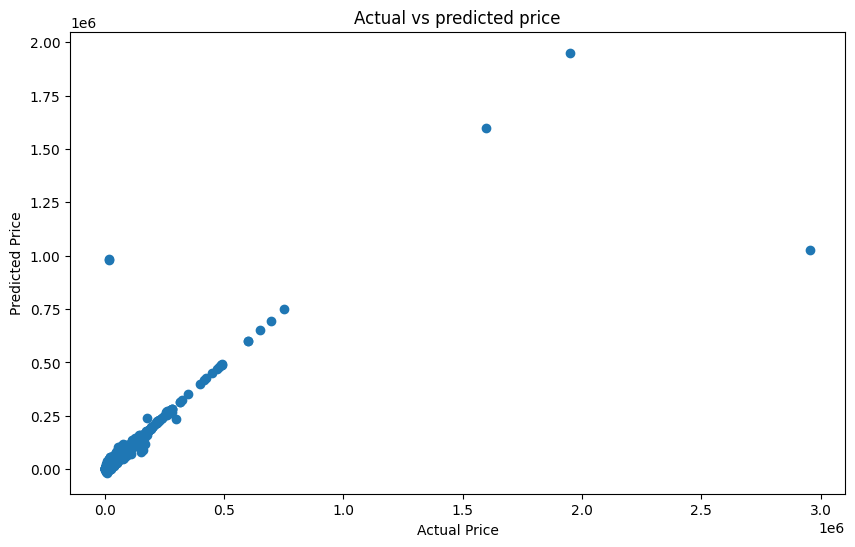

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(Y,Y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs predicted price")
plt.show()

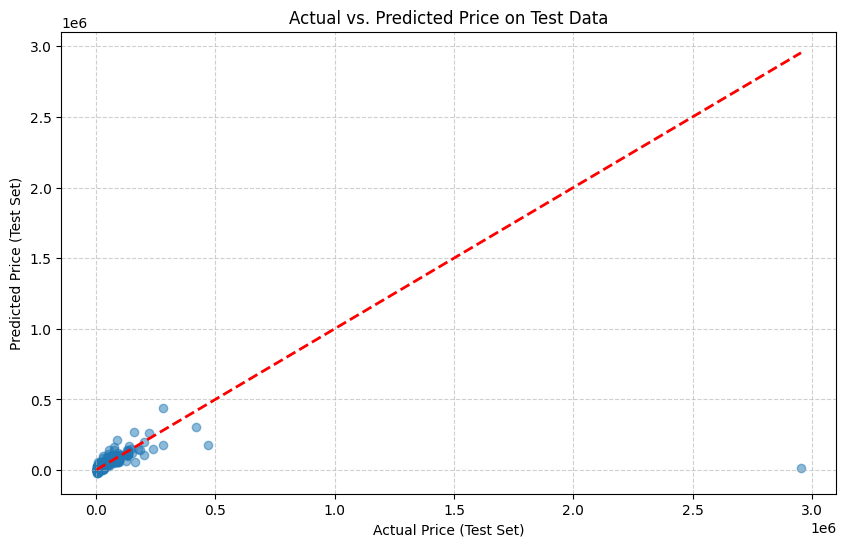

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(Y_test, Y_pred_split, alpha=0.5)
plt.xlabel("Actual Price (Test Set)")
plt.ylabel("Predicted Price (Test Set)")
plt.title("Actual vs. Predicted Price on Test Data")
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--', linewidth=2) # Add a perfect prediction line
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Model Evaluation: R-squared Score

In [ ]:
#Calculate the R-Squared score '
r2=r2_score(Y,Y_pred)
print(f"R-squared score:{r2:.4f}")
print(f"R-squared score: {r2:.4f}")

R-squared score:0.7456
R-squared score: 0.7456


In [ ]:
overall_mse = mean_squared_error(Y,Y_pred)
print(f"Mean Squared Error on full dataset:{overall_mse:.4f}")
overall_mae = mean_absolute_error(Y,Y_pred)
print(f"Mean Absolute Error on full dataset: {overall_mae:.4f}")


Mean Squared Erorr:1754027250.790923
mean absolute error: 4553.689012


In [ ]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

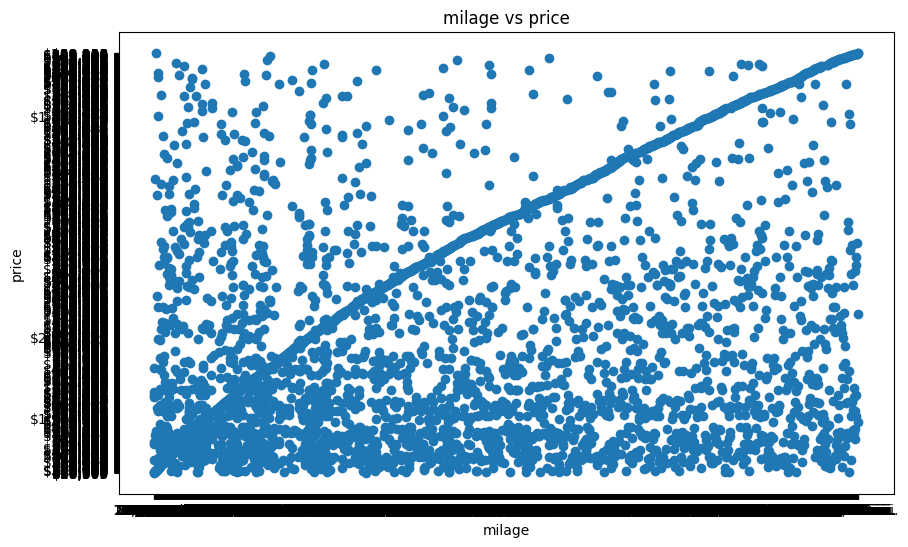

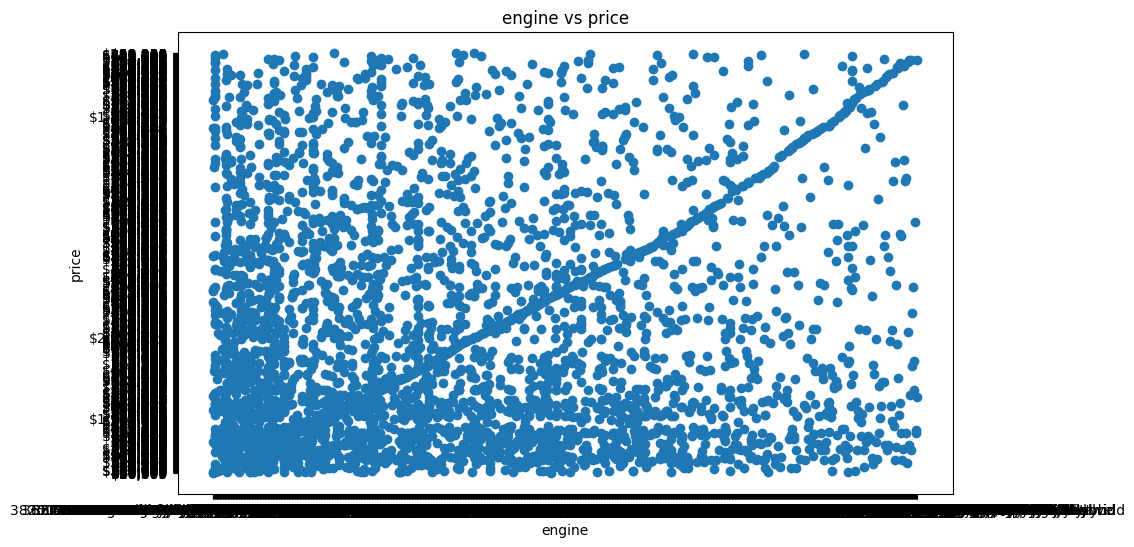

In [ ]:
num_col= ["milage" , "engine" ]
for col in num_col:
  plt.figure(figsize=(10,6))
  # Corrected: provide both x and y arguments for scatter plot
  # Removed kde=True as it's not a valid argument for plt.scatter
  plt.scatter(x=df[col], y=df["price"])
  # Corrected: plt.label to plt.xlabel to set the x-axis label
  plt.xlabel(col)
  plt.ylabel("price") # Added y-axis label for clarity
  plt.title(f'{col} vs price')
  plt.show()

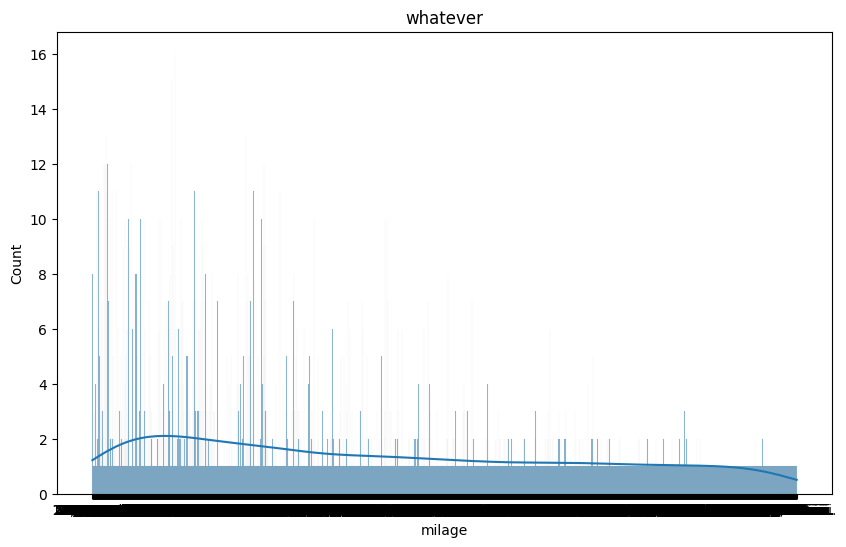

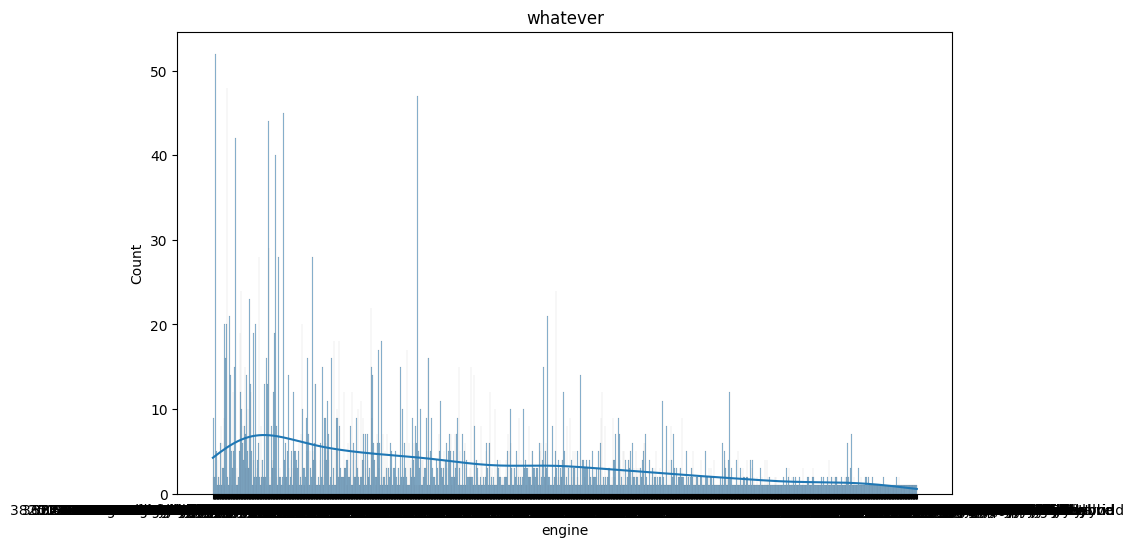

In [ ]:
num_col=["milage","engine"]
for col in num_col:
  plt.figure(figsize=(10,6))
  sns.histplot(df[col] , kde=True)
  plt.title("whatever")
  plt.show()
